In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# DataSet Loadign
df = pd.read_csv("Telco-Customer-Churn.csv")
print("Initial Data Shape: ", df.shape)
display(df.head())

Initial Data Shape:  (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
# Data Cleaning
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# search and fill Missing values
print("\nMissing values: \n", df.isnull().sum())
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True )


Missing values: 
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


/tmp/ipykernel_1888/3600270849.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True )


In [7]:
# Convert Churn column into numerical (0 and 1) for analysis
df['Churn_Numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)
print("\ndata Cleaned & Prepared Successfully!")


data Cleaned & Prepared Successfully!


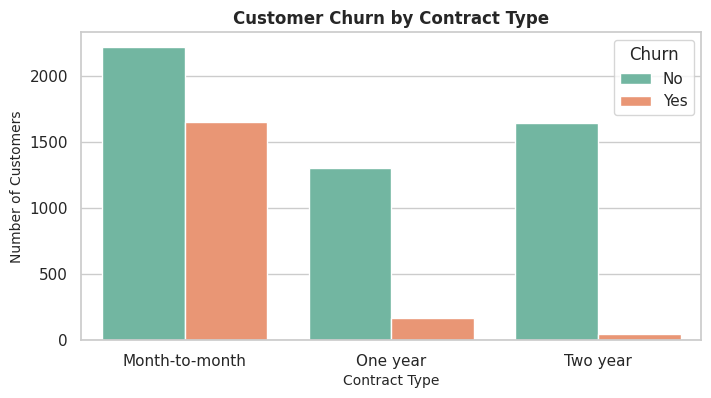

In [12]:
# Set Style
sns.set_theme(style="whitegrid")

# Contract type vs Churn Count Plot
plt.figure(figsize=(8,4))
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')
plt.title('Customer Churn by Contract Type', fontsize=12, fontweight='bold')
plt.xlabel('Contract Type', fontsize= 10)
plt.ylabel('Number of Customers', fontsize=10)
plt.show()

/tmp/ipykernel_1888/3084427877.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='Pastel1')


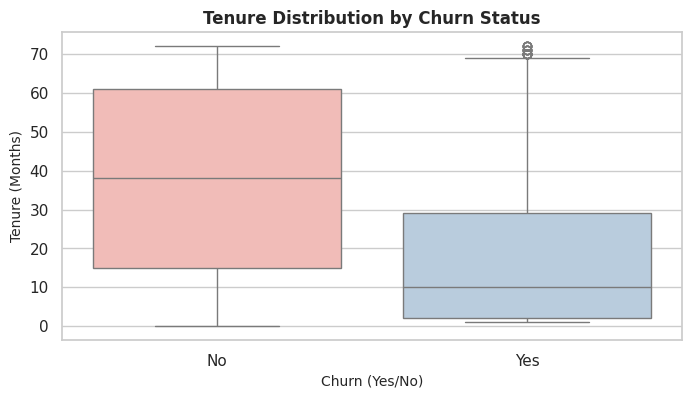

In [11]:
# Tenure vs Churn (Boxplot)
plt.figure(figsize=(8,4))
sns.boxplot(x='Churn', y='tenure', data=df, palette='Pastel1')
plt.title('Tenure Distribution by Churn Status', fontsize=12, fontweight='bold')
plt.xlabel('Churn (Yes/No)', fontsize=10)
plt.ylabel('Tenure (Months)', fontsize=10)
plt.show()

In [14]:
import sqlite3
#1. Create SQLite Databse
conn = sqlite3.connect('telecom_churn_project.db')
cusrsor= conn.cursor()

# 2. Convert Dataframe into SQL table
df.to_sql('cleaned_telco_churn', conn, if_exists='replace', index=False)

# SQL Query: Churn Rae by Contract Type
query_churn_contract = """
SELECT
  Contract,
  COUNT(customerID) AS Total_Customers,
  SUM(Churn_Numeric) AS Churn_Count,
  Round(CAST(SUM(Churn_Numeric) AS REAL) / COUNT(customerID) * 100, 2) AS Churn_Rate_Percentage
FROM
  cleaned_telco_churn
GROUP BY
  Contract;
"""

df_churn_contract = pd.read_sql_query(query_churn_contract, conn)
print("--- Churn Rate by Contract Type ---")
display(df_churn_contract)

--- Churn Rate by Contract Type ---


,Contract,Total_Customers,Churn_Count,Churn_Rate_Percentage
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


In [16]:
df.to_csv('Cleaned_telco_churn.csv', index=False)
print("File saved successfully!")

File saved successfully!
